# When a tune has no solution: read the convergence

Not every target frequency is reachable. If a cell cannot resonate at the requested
frequency by moving its tune variable, the tune **fails** — and the right thing to do is
**look at the convergence plot**, which is now saved even when the tune fails.

This example uses a 2-cell built from the C3795 dimensions with the iris widened to
80 mm, tuned to the **801.58 MHz** design frequency. The end cell cannot reach it by
varying its length, so the tune fails; the convergence makes the reason plain.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, minimize_scalar

from cavsim2d import Study, EllipticalCavity
from cavsim2d.utils.printing import set_verbose

set_verbose(False)

F = 801.58                                                   # design frequency [MHz]
# C3795 dimensions: A, B, a, b, Ri, L, Req  [mm]; iris widened to Ri = 80 everywhere
MID = [62.22, 66.13, 30.22, 23.11, 80, 93.5, 171.20]
END = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]

## 1. The tune fails

Tune each cell to `f` — `Req` for the mid cell, `L` for the end cell. The end-cell stage
cannot reach the target, so `cav.tuned` is `None`.

In [2]:
study = Study(os.path.join(tempfile.mkdtemp(), 'c3795_ri80'))
study.add_cavity([EllipticalCavity(2, MID, END, END, beampipe='both', name='C3795')], ['C3795'])
study.run_tune({'freqs': F, 'processes': 1, 'tol': 1e-3,
                'cell_type': {'mid-cell': 'Req', 'end-cell': 'L'},
                'eigenmode_config': {'processes': 1, 'boundary_conditions': 'mm'}})
cav = study.cavities_list[0]
print('\ntuned?  cav.tuned is', cav.tuned)

ERROR:: Tune did not reach target 801.58 MHz. Best |diff| = 3.929 MHz at L_el=95.53915654563991. Achievable freq range (sampled): [789.620, 797.651] MHz. Target may be unreachable by varying L_el alone — consider adjusting other geometry parameters (e.g., Req).
ERROR:: Done Tuning Cavity C3795 [end-cell: L_el]: Failed
ERROR:: Tune stage produced no result for C3795: cell_type=end-cell var=L
ERROR:: Tune results not found. Please tune the cavity

tuned?  cav.tuned is None


## 2. Read the convergence (saved even on failure)

The convergence history is persisted whether or not the tune succeeds, so
`cav.tune.plot_convergence()` works here — with the **target frequency** drawn as a
dashed line. The mid-cell stage reaches it; the **end-cell stage plateaus below it**.

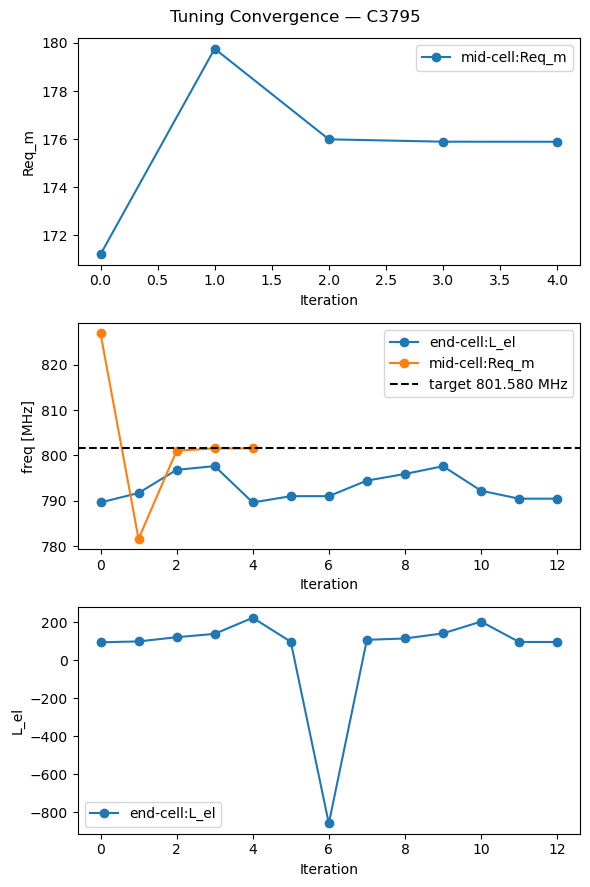

(<Figure size 600x900 with 3 Axes>,
 array([<Axes: xlabel='Iteration', ylabel='Req_m'>,
        <Axes: xlabel='Iteration', ylabel='freq [MHz]'>,
        <Axes: xlabel='Iteration', ylabel='L_el'>], dtype=object))

In [3]:
cav.tune.plot_convergence()

## 3. Why there is no solution

The tuner tunes the end cell in a **reduced model** (end cell + beam pipe). Map its
accelerating frequency against the end-cell length `L`: it rises but **asymptotes below
the target**, so no `L` makes it resonate at `f`.

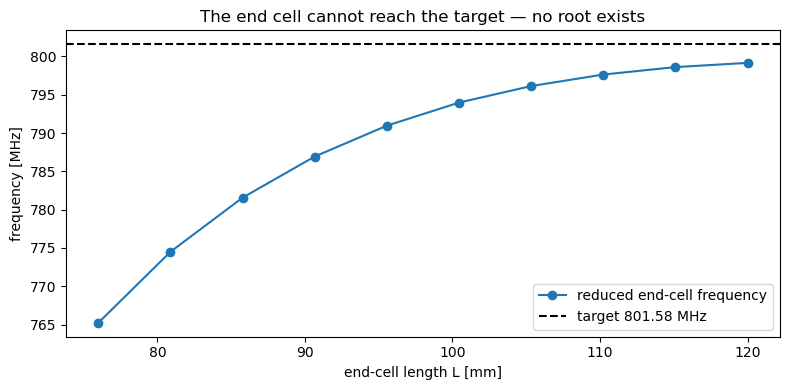

reachable end-cell frequency: [765.2, 799.2] MHz  vs target 801.58 MHz


In [4]:
conv = cav.tune.convergence
req_star = float(conv[(conv['stage'] == 'mid-cell:Req_m')
                      & (conv['parameter'] == 'Req_m')]['value'].iloc[-1])

def end_freq(L):
    '''Accelerating frequency of the reduced end-cell model (1 cell + beam pipe).'''
    cell = [62.58, 57.54, 17.21, 12, 80, float(L), req_star]
    c = EllipticalCavity(1, cell, cell, cell, beampipe='left')
    if c.profile() is None:
        return np.nan
    c.set_workspace(tempfile.mkdtemp())
    try:
        c.eigenmode.run(mesh_config={'h': 20, 'p': 2}, n_modes=2)
        d = c.eigenmode.qois_df.query('m == 0')
        return float(d.loc[d['R/Q [Ohm]'].idxmax()]['freq [MHz]'])
    except Exception:
        return np.nan

Ls = np.linspace(76, 120, 10)
fs = np.array([end_freq(L) for L in Ls])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(Ls, fs, 'o-', label='reduced end-cell frequency')
ax.axhline(F, ls='--', color='k', label='target %.2f MHz' % F)
ax.set_xlabel('end-cell length L [mm]'); ax.set_ylabel('frequency [MHz]')
ax.set_title('The end cell cannot reach the target — no root exists')
ax.legend(); plt.tight_layout(); plt.show()
print('reachable end-cell frequency: [%.1f, %.1f] MHz  vs target %.2f MHz'
      % (np.nanmin(fs), np.nanmax(fs), F))

## 4. The root-finder: secant vs a bounded search

cavsim2d tunes with a **secant** root-finder, which is *unbracketed* — with no root it can
extrapolate to **non-physical** lengths (the convergence in §2 shows `L_el` diving to a
large negative value). A **bounded** search instead stays inside a physical `L` range.

**What sets the bounds?** The *geometry*: below `L_min` the end-cell profile degenerates
(the iris and equator ellipses overlap, so `profile()` returns `None`); `L_max` is a
generous practical limit. We find `L_min` by walking `L` down until the profile breaks.

physical L range: [74.0, 130.0] mm  (profile degenerates below 74.0 mm)


secant : 17 evaluations, L in [ -645.1,  151.2] mm  (wanders out of range)


bounded: 28 evaluations, L in [   95.4,  126.0] mm  -> best f=799.37 (|diff|=2.21 MHz)


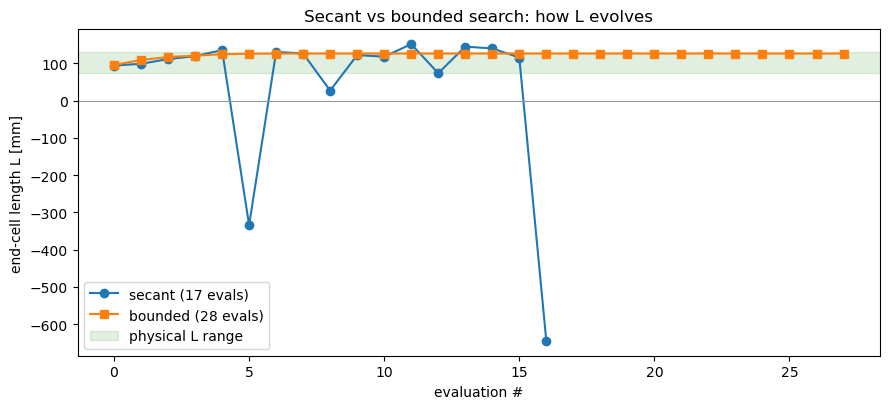

In [5]:
def valid(L):
    cell = [62.58, 57.54, 17.21, 12, 80, float(L), req_star]
    return EllipticalCavity(1, cell, cell, cell, beampipe='left').profile() is not None

L_min = min(L for L in np.arange(60, 100, 0.5) if valid(L))     # degenerate below this
L_max = 130.0
print('physical L range: [%.1f, %.1f] mm  (profile degenerates below %.1f mm)' % (L_min, L_max, L_min))

# current algorithm: the secant (records every L it evaluates)
secant_Ls = []
def g(L):
    secant_Ls.append(float(L))
    f = end_freq(L)
    return (f - F) if np.isfinite(f) else 50.0    # penalty on non-physical L, no crash
try:
    root_scalar(g, method='secant', x0=93.795, x1=93.795 * 1.05, xtol=1e-8, rtol=1e-8, maxiter=15)
except Exception:
    pass

# alternative: a bounded search minimising |freq - target| over the physical range
bounded_Ls = []
def h(L):
    bounded_Ls.append(float(L))
    f = end_freq(L)
    return abs(f - F) if np.isfinite(f) else 50.0
res = minimize_scalar(h, bounds=(L_min, L_max), method='bounded')

print('secant : %2d evaluations, L in [%7.1f, %6.1f] mm  (wanders out of range)'
      % (len(secant_Ls), min(secant_Ls), max(secant_Ls)))
print('bounded: %2d evaluations, L in [%7.1f, %6.1f] mm  -> best f=%.2f (|diff|=%.2f MHz)'
      % (len(bounded_Ls), min(bounded_Ls), max(bounded_Ls), end_freq(res.x), res.fun))

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(range(len(secant_Ls)), secant_Ls, 'o-', label='secant (%d evals)' % len(secant_Ls))
ax.plot(range(len(bounded_Ls)), bounded_Ls, 's-', label='bounded (%d evals)' % len(bounded_Ls))
ax.axhspan(L_min, L_max, color='green', alpha=0.12, label='physical L range')
ax.axhline(0, color='0.6', lw=0.8)
ax.set_xlabel('evaluation #'); ax.set_ylabel('end-cell length L [mm]')
ax.set_title('Secant vs bounded search: how L evolves')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Timing: secant vs bounded on a tune that *does* converge

The end-cell case had no solution. For a tune that **converges** — the mid cell, tuning
`Req` to `f` — the secant's fast (superlinear) convergence is a real advantage. Here we
run both methods on the mid-cell periodic model and compare evaluations and wall time
(both land on the same answer).

secant :  5 evaluations,  12.5 s  -> Req = 174.631 mm  (f = 801.5800)


bounded: 18 evaluations,  40.7 s  -> Req = 174.631 mm  (f = 801.5801)
secant is 3.3x faster on this converging tune


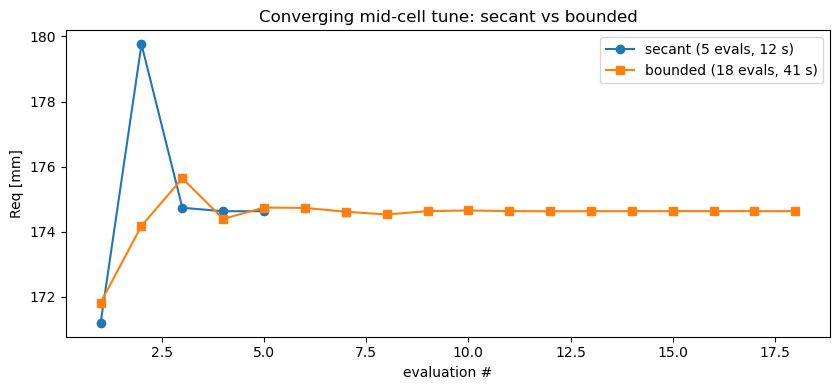

In [6]:
import time

def mid_freq(Req):
    '''Accelerating frequency of the periodic mid-cell model.'''
    mid = [62.22, 66.13, 30.22, 23.11, 80, 93.5, float(Req)]
    c = EllipticalCavity(1, mid, mid, mid, beampipe='none')
    c.set_workspace(tempfile.mkdtemp())
    c.eigenmode.run(mesh_config={'h': 20, 'p': 2}, n_modes=2)
    d = c.eigenmode.qois_df.query('m == 0')
    return float(d.loc[d['R/Q [Ohm]'].idxmax()]['freq [MHz]'])

class _Reached(Exception):
    pass

# secant with a frequency early-stop (how the tuner now converges)
sec = []
def _g(R):
    sec.append(float(R)); f = mid_freq(R)
    if abs(f - F) <= 1e-3:
        raise _Reached()
    return f - F
t0 = time.time()
try:
    root_scalar(_g, method='secant', x0=171.2, x1=171.2 * 1.05, xtol=1e-12, rtol=1e-12, maxiter=30)
except Exception:
    pass
t_sec = time.time() - t0

# bounded search over a physical Req range
bnd = []
def _h(R):
    bnd.append(float(R)); return abs(mid_freq(R) - F)
t0 = time.time()
minimize_scalar(_h, bounds=(168, 178), method='bounded', options={'xatol': 1e-4})
t_bnd = time.time() - t0

print('secant : %2d evaluations, %5.1f s  -> Req = %.3f mm  (f = %.4f)'
      % (len(sec), t_sec, sec[-1], mid_freq(sec[-1])))
print('bounded: %2d evaluations, %5.1f s  -> Req = %.3f mm  (f = %.4f)'
      % (len(bnd), t_bnd, bnd[-1], mid_freq(bnd[-1])))
print('secant is %.1fx faster on this converging tune' % (t_bnd / max(t_sec, 1e-9)))

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(range(1, len(sec) + 1), sec, 'o-', label='secant (%d evals, %.0f s)' % (len(sec), t_sec))
ax.plot(range(1, len(bnd) + 1), bnd, 's-', label='bounded (%d evals, %.0f s)' % (len(bnd), t_bnd))
ax.set_xlabel('evaluation #'); ax.set_ylabel('Req [mm]')
ax.set_title('Converging mid-cell tune: secant vs bounded')
ax.legend(); plt.tight_layout(); plt.show()

## Reading it

- A tune **fails when the target is unreachable** — here the end cell's reduced model
  asymptotes below `f`, so no length works.
- **The convergence is saved even on failure**, so `cav.tune.convergence` /
  `cav.tune.plot_convergence()` (with the target line) let you *see* it: the end-cell
  stage stuck below the target is the signature of "no solution".
- **Secant vs bounded is a trade-off.** On a *converging* tune (the mid cell, §5) the
  secant is much faster — ~4× fewer evaluations and wall time — thanks to its superlinear
  convergence. But it is unbracketed, so on a *hard* case (the end cell, §4) it wanders to
  non-physical lengths. A bounded search — bounds set by where the geometry degenerates —
  is slower but stays physical and reports the best reachable frequency instead of
  diverging. Secant for the common case; a bounded fallback for the hard ones.